# 5 · Aktivierungsfunktionen und Nichtlinearität

**Reihe:** Mathematische Grundlagen des Maschinellen Lernens · Notebook 5 von 5
**Voraussetzungen:** Notebooks 2 (Ableitungen, Konditionierung) und 4 (Softmax, Kreuzentropie)
**Bearbeitungszeit:** ca. 70 Minuten

---

### Zusammenfassung

Ohne Aktivierungsfunktionen ist ein neuronales Netz beliebiger Tiefe eine einzige affine
Abbildung — wir beweisen diese Aussage zuerst und leiten daraus die Notwendigkeit der
Nichtlinearität ab. Anschließend untersuchen wir die gebräuchlichen Aktivierungsfunktionen
analytisch: ihre Ableitungen, ihre Wertebereiche, ihre numerisch stabilen Implementierungen und
die Jacobi-Matrix der Softmax-Funktion. Der abschließende Abschnitt verbindet beides mit der
Optimierung: Ein numerisches Experiment zeigt, wie das Produkt der Ableitungen über die Schichten
den Gradienten exponentiell dämpft oder verstärkt, und weshalb eine varianzerhaltende
Initialisierung das Problem für ReLU-Netze behebt.

### Lernziele

Nach Bearbeitung dieses Notebooks können Sie

1. beweisen, dass die Komposition affiner Abbildungen affin ist, und die Konsequenz für tiefe
   lineare Netze benennen;
2. die Ableitungen von Sigmoid, Tanh und ReLU herleiten und ihre Wertebereiche angeben;
3. Sigmoid und Softmax numerisch stabil implementieren und die Fehlerquellen der naiven Form
   benennen;
4. die Verschiebungsinvarianz der Softmax-Funktion und ihre Jacobi-Matrix herleiten;
5. das Verschwinden bzw. Explodieren von Gradienten als Produkt schichtweiser Faktoren erklären;
6. die Initialisierungsregeln nach Glorot und He aus einer Varianzbetrachtung herleiten.

### Inhalt

1. [Warum Nichtlinearität notwendig ist](#1)
2. [Sigmoid und Tanh](#2)
3. [ReLU und ihre Varianten](#3)
4. [Softmax: Verschiebungsinvarianz und Jacobi-Matrix](#4)
5. [Gradientenfluss in tiefen Netzen](#5)
6. [Übungsaufgaben](#6)

## 0 Vorbereitung

Die folgende Zelle lädt die Abhängigkeiten, fixiert den Zufallsgenerator und setzt
das einheitliche Abbildungslayout der Reihe. Sie ist in allen Notebooks identisch
und muss vor allen weiteren Zellen ausgeführt werden.

In [1]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
from cycler import cycler

# Reproduzierbarkeit: fester Seed für alle stochastischen Experimente dieses Notebooks
SEED = 20260730
rng = np.random.default_rng(SEED)

# Einheitliches Abbildungslayout für die gesamte Notebook-Reihe.
# Die Farbfolge ist auf Farbfehlsichtigkeit geprüft (Blau, Orange, Aquamarin,
# Violett, Rot); benachbarte Serien sind sowohl in der Helligkeit als auch im
# Farbton unterscheidbar.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#4a3aa7", "#e34948"]

mpl.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 110,
    "figure.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.prop_cycle": cycler(color=PALETTE),
    "axes.grid": True,
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.labelcolor": "#0b0b0b",
    "grid.color": "#d8d7d2",
    "grid.linewidth": 0.6,
    "legend.frameon": False,
    "lines.linewidth": 2.0,
    "font.size": 10,
    "mathtext.fontset": "cm",
})

np.set_printoptions(precision=4, suppress=True)
print(f"NumPy {np.__version__} · Matplotlib {mpl.__version__} · Seed {SEED}")

NumPy 2.4.6 · Matplotlib 3.11.1 · Seed 20260730


<a id="1"></a>
## 1 Warum Nichtlinearität notwendig ist

> **Satz 1.1.** Seien $f_i(x) = W_i x + b_i$ affine Abbildungen, $i = 1,\dots,L$. Dann ist die
> Komposition $f_L \circ \dots \circ f_1$ affin; genauer gilt
> $$\big(f_L \circ \dots \circ f_1\big)(x) \;=\; W x + b
> \quad\text{mit}\quad W = W_L\cdots W_1, \qquad b = \sum_{i=1}^{L}\Big(\prod_{j=i+1}^{L} W_j\Big) b_i .$$
>
> *Beweis (Induktion über $L$).* Für $L=1$ ist nichts zu zeigen. Gelte die Aussage für $L-1$, also
> $(f_{L-1}\circ\dots\circ f_1)(x) = \tilde W x + \tilde b$. Dann ist
> $f_L(\tilde W x + \tilde b) = W_L \tilde W x + (W_L \tilde b + b_L)$, wieder von der behaupteten
> Form. $\square$

> **Korollar 1.2.** Ein Netz mit $L$ Schichten ohne Aktivierungsfunktion hat dieselbe
> Ausdrucksstärke wie ein Netz mit einer einzigen Schicht. Zusätzliche Tiefe erhöht lediglich die
> Parameterzahl — nicht die Menge der darstellbaren Funktionen.

Zudem ist der Rang beschränkt: $\operatorname{rang}(W_L\cdots W_1) \le \min_i \operatorname{rang}(W_i)$.
Ein tiefes lineares Netz mit einer schmalen Zwischenschicht kann also selbst als lineare Abbildung
nicht mehr leisten als diese Engstelle zulässt — die algebraische Grundlage der Hauptkomponenten\-analyse
im Autoencoder.

> **Satz 1.3 (Universelle Approximation; Cybenko 1989, Hornik 1991).** Sei
> $\varphi : \mathbb{R}\to\mathbb{R}$ stetig, beschränkt und nicht polynomial. Dann liegt die Menge
> der Funktionen $x \mapsto \sum_{j=1}^{m} c_j\,\varphi(w_j^\top x + b_j)$ dicht in
> $C(K)$ für jedes Kompaktum $K \subset \mathbb{R}^n$ bezüglich der Supremumsnorm.

Entscheidend ist die Voraussetzung **nicht polynomial**: Genau hier geht die Nichtlinearität ein.
Der Satz sagt allerdings nichts über die benötigte Breite $m$ — sie kann exponentiell in $n$
wachsen, und genau deshalb ist Tiefe in der Praxis dennoch wertvoll.

In [2]:
# Korollar 1.2 numerisch: ein tiefes lineares Netz ist exakt eine einzige Matrix
depth, width = 8, 6
Ws = [rng.normal(size=(width, width)) / np.sqrt(width) for _ in range(depth)]
x_batch = rng.normal(size=(5, width))

deep = x_batch.copy()
for W in Ws:
    deep = deep @ W

collapsed = np.linalg.multi_dot(Ws)
print(f"maximale Abweichung tiefes Netz vs. Produktmatrix: "
      f"{np.max(np.abs(deep - x_batch @ collapsed)):.3e}")

# Rangschranke bei einer Engstelle
Ws_bottleneck = [rng.normal(size=(20, 20)), rng.normal(size=(20, 3)), rng.normal(size=(3, 20))]
print(f"\nRänge der Faktoren: {[np.linalg.matrix_rank(W) for W in Ws_bottleneck]}")
print(f"Rang des Produkts:  {np.linalg.matrix_rank(np.linalg.multi_dot(Ws_bottleneck))}"
      f"   (beschränkt durch die Engstelle)")

maximale Abweichung tiefes Netz vs. Produktmatrix: 4.441e-16

Ränge der Faktoren: [np.int64(20), np.int64(3), np.int64(3)]
Rang des Produkts:  3   (beschränkt durch die Engstelle)


<a id="2"></a>
## 2 Sigmoid und Tanh

> **Definition 2.1.** $\displaystyle \sigma(x) = \frac{1}{1+e^{-x}}$ (logistische Funktion) und
> $\displaystyle \tanh(x) = \frac{e^{x}-e^{-x}}{e^{x}+e^{-x}}$.

> **Satz 2.2 (Eigenschaften).**
> 1. $\sigma'(x) = \sigma(x)\big(1-\sigma(x)\big)$, insbesondere
>    $0 < \sigma'(x) \le \sigma'(0) = \tfrac14$.
> 2. $\tanh(x) = 2\sigma(2x) - 1$, also $\tanh'(x) = 1 - \tanh^2(x) \le 1$.
> 3. $\sigma(-x) = 1-\sigma(x)$ (Punktsymmetrie zu $(0,\tfrac12)$).
>
> *Beweis.* (1) Quotientenregel:
> $\sigma'(x) = \frac{e^{-x}}{(1+e^{-x})^2} = \frac{1}{1+e^{-x}}\cdot\frac{e^{-x}}{1+e^{-x}}
> = \sigma(x)(1-\sigma(x))$. Das Maximum von $t(1-t)$ auf $[0,1]$ liegt bei $t=\tfrac12$, also
> $\sigma'\le \tfrac14$, angenommen bei $x=0$.
> (2) $2\sigma(2x)-1 = \frac{2}{1+e^{-2x}}-1 = \frac{1-e^{-2x}}{1+e^{-2x}} = \tanh(x)$ nach
> Erweitern mit $e^{x}$.
> (3) $\sigma(-x) = \frac{1}{1+e^{x}} = \frac{e^{-x}}{1+e^{-x}} = 1 - \sigma(x)$. $\square$

Aussage (1) ist folgenreich: Bei der Rückwärtspropagation wird pro Schicht mit einem Faktor
$\le \tfrac14$ multipliziert. Über $L$ Schichten schrumpft der Gradient damit selbst im
günstigsten Fall wie $4^{-L}$ — das *vanishing gradient problem* (Abschnitt 5).

**Numerische Stabilität.** Die Auswertung von $e^{-x}$ läuft für $x \lesssim -745$ über. Die
mathematisch äquivalente Umformung für negative Argumente
$$\sigma(x) = \frac{e^{x}}{1+e^{x}} \qquad (x < 0)$$
vermeidet das, da dort $e^{x} \in (0,1)$ liegt. Man wählt also je nach Vorzeichen die
Darstellung, in der der Exponent negativ ist.

In [3]:
def sigmoid(x):
    """Numerisch stabile logistische Funktion: fuer x < 0 wird die aequivalente
    Form e^x/(1+e^x) verwendet, sodass der Exponent nie positiv ist."""
    x = np.asarray(x, dtype=float)
    out = np.empty_like(x)
    pos, neg = x >= 0, x < 0
    out[pos] = 1.0 / (1.0 + np.exp(-x[pos]))
    e = np.exp(x[neg])
    out[neg] = e / (1.0 + e)
    return out


def naive_sigmoid(x):
    with np.errstate(over="ignore"):
        return 1.0 / (1.0 + np.exp(-np.asarray(x, dtype=float)))


def d_sigmoid(x):
    s = sigmoid(x)
    return s * (1.0 - s)


def log_sigmoid(x):
    """log sigma(x), stabil ohne Zwischenschritt ueber sigma selbst:
    fuer x >= 0 gilt -log1p(e^-x), fuer x < 0 gilt x - log1p(e^x)."""
    x = np.asarray(x, dtype=float)
    out = np.empty_like(x)
    pos = x >= 0
    out[pos] = -np.log1p(np.exp(-x[pos]))
    out[~pos] = x[~pos] - np.log1p(np.exp(x[~pos]))
    return out


# sigma selbst unterscheidet sich kaum - der Unterschied zeigt sich erst im Logarithmus,
# der in jeder Kreuzentropie steht (Notebook 4, Abschnitt 5).
extreme = np.array([-800.0, -50.0, 0.0, 50.0, 800.0])
print(f"{'x':>8} | {'sigma naiv':>13} | {'sigma stabil':>13} | "
      f"{'log sigma naiv':>15} | {'log sigma stabil':>17}")
print("-" * 78)
with np.errstate(over="ignore", divide="ignore"):
    for xi in extreme:
        s_naive = naive_sigmoid(xi)
        s_stable = sigmoid(np.array([xi]))[0]
        print(f"{xi:>8.1f} | {s_naive:>13.4e} | {s_stable:>13.4e} | "
              f"{np.log(s_naive):>15.4f} | {log_sigmoid(np.array([xi]))[0]:>17.4f}")

# Satz 2.2 numerisch pruefen
xs = np.linspace(-6, 6, 1001)
print(f"\nmax |tanh(x) - (2*sigmoid(2x) - 1)| = {np.max(np.abs(np.tanh(xs) - (2 * sigmoid(2 * xs) - 1))):.2e}")
print(f"max sigma'(x) = {d_sigmoid(xs).max():.6f}   (Theorie: 0,25 bei x = 0)")
print(f"max tanh'(x)  = {np.max(1 - np.tanh(xs) ** 2):.6f}   (Theorie: 1 bei x = 0)")

       x |    sigma naiv |  sigma stabil |  log sigma naiv |  log sigma stabil
------------------------------------------------------------------------------
  -800.0 |    0.0000e+00 |    0.0000e+00 |            -inf |         -800.0000
   -50.0 |    1.9287e-22 |    1.9287e-22 |        -50.0000 |          -50.0000
     0.0 |    5.0000e-01 |    5.0000e-01 |         -0.6931 |           -0.6931
    50.0 |    1.0000e+00 |    1.0000e+00 |          0.0000 |           -0.0000
   800.0 |    1.0000e+00 |    1.0000e+00 |          0.0000 |           -0.0000

max |tanh(x) - (2*sigmoid(2x) - 1)| = 3.33e-16
max sigma'(x) = 0.250000   (Theorie: 0,25 bei x = 0)
max tanh'(x)  = 1.000000   (Theorie: 1 bei x = 0)


Die Tabelle zeigt, wo das Problem tatsächlich liegt. In $\sigma$ selbst unterscheiden sich beide
Implementierungen kaum: Die naive Form läuft bei $x=-800$ zwar über ($e^{800} = \infty$ im Nenner)
und erkauft das mit einer `RuntimeWarning`, liefert aber zufällig den richtigen Grenzwert $0$.
Fatal wird es erst im **Logarithmus**, und der steht in jeder Kreuzentropie: $\log 0 = -\infty$
zerstört den gesamten Batch-Verlust, während $\log\sigma(-800) = -800$ der korrekte endliche Wert
ist. Deshalb bieten alle Frameworks `logsigmoid` bzw. `binary_cross_entropy_with_logits` als
eigene Operation an — man soll $\sigma$ und $\log$ gar nicht erst getrennt auswerten.

<a id="3"></a>
## 3 ReLU und ihre Varianten

> **Definition 3.1.** $\operatorname{ReLU}(x) = \max(0, x)$.

$\operatorname{ReLU}$ ist an $x=0$ **nicht differenzierbar**; als konvexe Funktion besitzt sie dort
jedoch das Subdifferential $\partial \operatorname{ReLU}(0) = [0,1]$. Implementierungen wählen
konventionell den Wert $0$. Da $\{0\}$ eine Nullmenge ist und die Trainingsdaten sie fast sicher
nicht exakt treffen, ist die Wahl praktisch folgenlos.

| Funktion | Definition | Ableitung | Wertebereich | Bemerkung |
|---|---|---|---|---|
| ReLU | $\max(0,x)$ | $\mathbb{1}[x>0]$ | $[0,\infty)$ | Gradient $1$ auf dem positiven Ast |
| Leaky ReLU | $\max(\alpha x, x)$ | $1$ bzw. $\alpha$ | $\mathbb{R}$ | verhindert dauerhaft tote Neuronen |
| ELU | $x$ bzw. $\alpha(e^{x}-1)$ | $1$ bzw. $\alpha e^{x}$ | $(-\alpha,\infty)$ | stetig differenzierbar für $\alpha=1$ |
| GELU | $x\,\Phi(x)$ | $\Phi(x) + x\varphi(x)$ | $\approx(-0{,}17,\infty)$ | glatt; Standard in Transformer-Modellen |

Dabei bezeichnen $\Phi$ und $\varphi$ Verteilungs- und Dichtefunktion der Standardnormalverteilung.

Der entscheidende Vorteil gegenüber Sigmoid: Auf dem aktiven Ast ist die Ableitung exakt $1$, das
Produkt über die Schichten wird also nicht systematisch gedämpft. Der Preis ist das *dying ReLU*:
Ein Neuron, dessen Eingang dauerhaft negativ ist, erhält den Gradienten $0$ und wird nie wieder
aktualisiert. Leaky ReLU und ELU halten mit $\alpha > 0$ einen Restgradienten aufrecht.

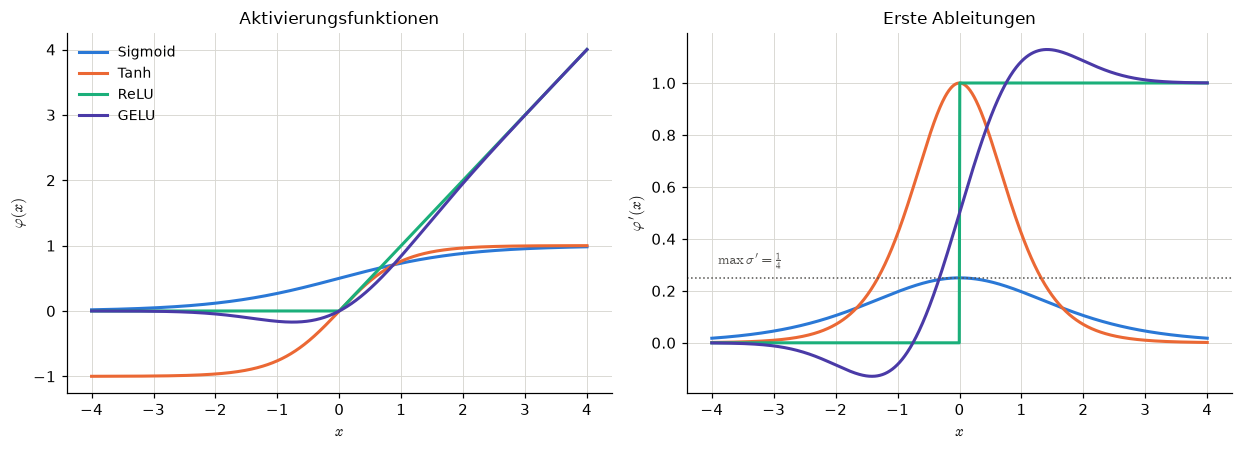

Funktion   | max |analytisch - Zentraldifferenz|
------------------------------------------------
Sigmoid    | 1.262e-10
Tanh       | 7.277e-11
ReLU       | 1.398e-10
GELU       | 4.587e-10


In [4]:
from scipy.special import erf                       # fuer GELU


def relu(x):
    return np.maximum(0.0, np.asarray(x, dtype=float))


def d_relu(x):
    return (np.asarray(x, dtype=float) > 0).astype(float)


def leaky_relu(x, alpha=0.1):
    x = np.asarray(x, dtype=float)
    return np.where(x > 0, x, alpha * x)


def d_leaky_relu(x, alpha=0.1):
    return np.where(np.asarray(x, dtype=float) > 0, 1.0, alpha)


def elu(x, alpha=1.0):
    x = np.asarray(x, dtype=float)
    return np.where(x > 0, x, alpha * (np.exp(np.minimum(x, 0.0)) - 1.0))


def d_elu(x, alpha=1.0):
    x = np.asarray(x, dtype=float)
    return np.where(x > 0, 1.0, alpha * np.exp(np.minimum(x, 0.0)))


def gelu(x):
    x = np.asarray(x, dtype=float)
    return x * 0.5 * (1.0 + erf(x / np.sqrt(2.0)))


def d_gelu(x):
    x = np.asarray(x, dtype=float)
    Phi = 0.5 * (1.0 + erf(x / np.sqrt(2.0)))
    phi = np.exp(-0.5 * x ** 2) / np.sqrt(2 * np.pi)
    return Phi + x * phi


grid = np.linspace(-4, 4, 1000)
functions = [
    ("Sigmoid", sigmoid, d_sigmoid),
    ("Tanh", np.tanh, lambda x: 1 - np.tanh(x) ** 2),
    ("ReLU", relu, d_relu),
    ("GELU", gelu, d_gelu),
]

fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.2))
for (name, f, df), color in zip(functions, PALETTE):
    axes[0].plot(grid, f(grid), color=color, label=name)
    axes[1].plot(grid, df(grid), color=color, label=name)

axes[0].set_title("Aktivierungsfunktionen")
axes[0].set_xlabel("$x$")
axes[0].set_ylabel(r"$\varphi(x)$")
axes[0].legend(fontsize=9, loc="upper left")

axes[1].axhline(0.25, color="#52514e", linestyle=":", linewidth=1.0)
axes[1].text(-3.9, 0.30, r"$\max \sigma' = \frac{1}{4}$", fontsize=9, color="#52514e")
axes[1].set_title("Erste Ableitungen")
axes[1].set_xlabel("$x$")
axes[1].set_ylabel(r"$\varphi'(x)$")

plt.tight_layout()
plt.show()

# Kontrolle der analytischen Ableitungen gegen die Zentraldifferenz (Notebook 2, Satz 2.1)
h = 1e-6
print(f"{'Funktion':<10} | max |analytisch - Zentraldifferenz|")
print("-" * 48)
for name, f, df in functions:
    x_test = np.linspace(-4, 4, 401)
    x_test = x_test[np.abs(x_test) > 1e-3]          # ReLU ist in 0 nicht differenzierbar
    numeric = (f(x_test + h) - f(x_test - h)) / (2 * h)
    print(f"{name:<10} | {np.max(np.abs(df(x_test) - numeric)):.3e}")

**Abbildung 5.1** — Links die Funktionen, rechts ihre Ableitungen. Die für das Training
entscheidende Aussage steht in der rechten Grafik: Sigmoid und Tanh haben Ableitungen, die
außerhalb eines schmalen Bereichs um $0$ praktisch verschwinden (*Sättigung*), während ReLU und
GELU auf dem gesamten positiven Ast eine Ableitung nahe $1$ behalten. Die gepunktete Linie
markiert die in Satz 2.2 bewiesene Schranke $\sigma' \le \tfrac14$.

<a id="4"></a>
## 4 Softmax: Verschiebungsinvarianz und Jacobi-Matrix

> **Definition 4.1.** Für $z \in \mathbb{R}^n$ ist
> $\displaystyle \operatorname{softmax}(z)_i = \frac{e^{z_i}}{\sum_{j=1}^n e^{z_j}}$.
> Die Ausgabe ist eine Wahrscheinlichkeitsverteilung.

> **Satz 4.2 (Verschiebungsinvarianz).** Für alle $c \in \mathbb{R}$ gilt
> $\operatorname{softmax}(z + c\mathbf{1}) = \operatorname{softmax}(z)$.
>
> *Beweis.* $\dfrac{e^{z_i+c}}{\sum_j e^{z_j+c}} = \dfrac{e^{c}e^{z_i}}{e^{c}\sum_j e^{z_j}}
> = \dfrac{e^{z_i}}{\sum_j e^{z_j}}$. $\square$

Satz 4.2 ist die Grundlage der stabilen Implementierung: Man wählt $c = -\max_i z_i$, sodass alle
Exponenten $\le 0$ sind (vgl. Notebook 4, Abschnitt 5). Die Aussage bedeutet zugleich, dass die
Parametrisierung **überbestimmt** ist — nur $n-1$ der $n$ Logits sind identifizierbar.

> **Satz 4.3 (Jacobi-Matrix).** Mit $s = \operatorname{softmax}(z)$ gilt
> $$\frac{\partial s_i}{\partial z_j} \;=\; s_i\,(\delta_{ij} - s_j),
> \qquad\text{in Matrixform}\quad J = \operatorname{diag}(s) - s\,s^\top .$$
>
> *Beweis.* Für $i=j$ liefert die Quotientenregel mit $S = \sum_k e^{z_k}$:
> $\partial_i \frac{e^{z_i}}{S} = \frac{e^{z_i}S - e^{z_i}e^{z_i}}{S^2} = s_i - s_i^2 = s_i(1-s_i)$.
> Für $i \ne j$: $\partial_j \frac{e^{z_i}}{S} = -\frac{e^{z_i}e^{z_j}}{S^2} = -s_i s_j$. $\square$

> **Korollar 4.4.** $J$ ist symmetrisch und positiv semidefinit mit $J\mathbf{1} = 0$: Der
> Verschiebungsrichtung $\mathbf{1}$ entspricht der Eigenwert $0$, in Übereinstimmung mit Satz 4.2.
> Für $n = 2$ reduziert sich Softmax auf die logistische Funktion:
> $\operatorname{softmax}(z)_1 = \sigma(z_1 - z_2)$.

In [5]:
def softmax(z, axis=-1):
    """Softmax mit Verschiebung um das Maximum (Satz 4.2)."""
    z = np.asarray(z, dtype=float)
    e = np.exp(z - np.max(z, axis=axis, keepdims=True))
    return e / np.sum(e, axis=axis, keepdims=True)


def softmax_jacobian(z):
    s = softmax(z)
    return np.diag(s) - np.outer(s, s)


z = np.array([2.0, 0.5, -1.0, 0.25])
s = softmax(z)
J = softmax_jacobian(z)

# Satz 4.3 gegen die Zentraldifferenz pruefen
h = 1e-6
J_numeric = np.empty_like(J)
for j in range(len(z)):
    e_j = np.zeros_like(z)
    e_j[j] = h
    J_numeric[:, j] = (softmax(z + e_j) - softmax(z - e_j)) / (2 * h)

print(f"softmax(z) = {s},  Summe = {s.sum():.12f}")
print(f"max |J_analytisch - J_numerisch| = {np.max(np.abs(J - J_numeric)):.3e}\n")

print(f"Verschiebungsinvarianz: max |softmax(z) - softmax(z + 1000)| = "
      f"{np.max(np.abs(softmax(z) - softmax(z + 1000))):.2e}")
print(f"J * 1 = {J @ np.ones_like(z) + 0.0}   (Korollar 4.4)")
print(f"Eigenwerte von J: {np.sort(np.linalg.eigvalsh(J))}   -> positiv semidefinit")

z2 = np.array([1.3, -0.4])
print(f"\nn = 2: softmax(z)_1 = {softmax(z2)[0]:.12f}, "
      f"sigma(z_1 - z_2) = {sigmoid(np.array([z2[0] - z2[1]]))[0]:.12f}")

softmax(z) = [0.6912 0.1542 0.0344 0.1201],  Summe = 1.000000000000
max |J_analytisch - J_numerisch| = 5.253e-11

Verschiebungsinvarianz: max |softmax(z) - softmax(z + 1000)| = 0.00e+00
J * 1 = [-0. -0. -0. -0.]   (Korollar 4.4)
Eigenwerte von J: [-0.      0.043   0.1341  0.3057]   -> positiv semidefinit

n = 2: softmax(z)_1 = 0.845534734916, sigma(z_1 - z_2) = 0.845534734916


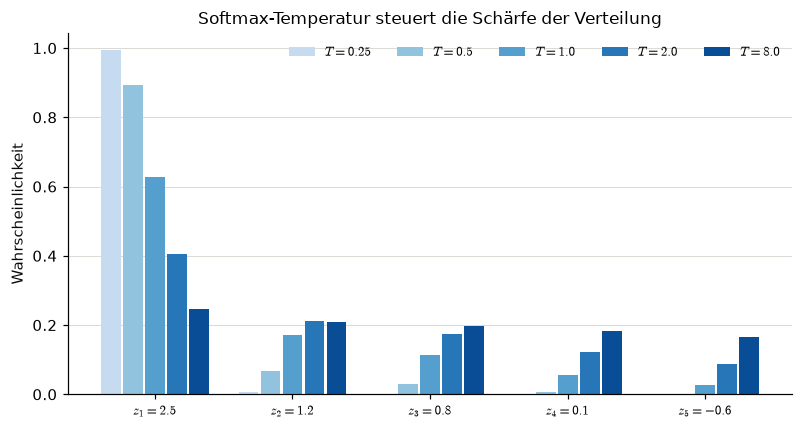

T = 0.25:  max p = 0.9933,  H = 0.0626 bit
T =  0.5:  max p = 0.8945,  H = 0.6237 bit
T =  1.0:  max p = 0.6285,  H = 1.5969 bit
T =  2.0:  max p = 0.4060,  H = 2.1164 bit
T =  8.0:  max p = 0.2452,  H = 2.3092 bit


In [6]:
# Temperatur: skalierte Logits interpolieren zwischen Gleichverteilung und Argmax
logits = np.array([2.5, 1.2, 0.8, 0.1, -0.6])
temperatures = [0.25, 0.5, 1.0, 2.0, 8.0]

fig, ax = plt.subplots(figsize=(7.4, 4.0))
positions = np.arange(len(logits))
width = 0.16

for k, T in enumerate(temperatures):
    p_T = softmax(logits / T)
    ax.bar(positions + (k - 2) * width, p_T, width=width * 0.9,
           color=plt.cm.Blues(0.25 + 0.16 * k), label=f"$T={T}$")

ax.set_xticks(positions)
ax.set_xticklabels([f"$z_{i+1}={v}$" for i, v in enumerate(logits)], fontsize=8.5)
ax.set_ylabel("Wahrscheinlichkeit")
ax.set_title("Softmax-Temperatur steuert die Schärfe der Verteilung")
ax.legend(fontsize=8.5, ncol=5)
ax.grid(axis="x", visible=False)
plt.tight_layout()
plt.show()

for T in temperatures:
    p_T = softmax(logits / T)
    h = float(-np.sum(p_T * np.log2(p_T)))
    print(f"T = {T:>4}:  max p = {p_T.max():.4f},  H = {h:.4f} bit")

**Abbildung 5.2** — Softmax-Verteilung für dieselben Logits bei verschiedenen Temperaturen. Der
Grenzfall $T\to 0$ ergibt die Punktmasse auf dem größten Logit (harter Argmax), $T\to\infty$ die
Gleichverteilung. Die Entropiewerte darunter quantifizieren denselben Übergang und schließen an
Abbildung 4.1 (rechts) an.

<a id="5"></a>
## 5 Gradientenfluss in tiefen Netzen

Für ein Netz $a^{(\ell)} = \varphi\big(W^{(\ell)} a^{(\ell-1)}\big)$ liefert die Kettenregel für
den Fehlerterm $\delta^{(\ell)} = \partial \mathcal{L}/\partial z^{(\ell)}$ die Rekursion
$$\delta^{(\ell)} \;=\; \Big(\big(W^{(\ell+1)}\big)^{\!\top}\delta^{(\ell+1)}\Big) \odot \varphi'\big(z^{(\ell)}\big).$$
Der Gradient der frühen Schichten ist damit ein **Produkt** aus $L-\ell$ Faktoren. Grob gilt für
die Norm
$$\big\|\delta^{(\ell)}\big\| \;\sim\; \prod_{k=\ell+1}^{L} \underbrace{\big\|W^{(k)}\big\| \cdot \big\lvert\varphi'\big\rvert}_{=:\,\gamma_k}.$$
Ist der typische Faktor $\gamma < 1$, fällt die Norm exponentiell in der Tiefe (*vanishing
gradients*); ist $\gamma > 1$, wächst sie exponentiell (*exploding gradients*). Nur $\gamma \approx 1$
erlaubt das Training sehr tiefer Netze.

> **Initialisierung.** Sei $z = W a$ mit unabhängigen Einträgen $W_{ij} \sim (0, \varsigma^2)$ und
> Eingangsdimension $n_{\text{in}}$. Dann ist
> $\operatorname{Var}(z_i) = n_{\text{in}}\,\varsigma^2 \operatorname{Var}(a_j)$. Varianzerhaltung
> verlangt also $\varsigma^2 = 1/n_{\text{in}}$ — die Regel von **Glorot & Bengio (2010)** für
> symmetrische Aktivierungen. Für ReLU wird die Hälfte der Einheiten auf null gesetzt, was die
> Varianz halbiert; der Ausgleich ist $\varsigma^2 = 2/n_{\text{in}}$ — die Regel von
> **He et al. (2015)**.

Wir messen beide Effekte an zufällig initialisierten Netzen.

In [7]:
def propagate(activation, d_activation, depth=40, width=128, batch=64, gain=1.0, rng=rng):
    """Vorwaerts- und Rueckwaertsdurchlauf durch ein zufaellig initialisiertes Netz.

    Rueckgabe: Standardabweichung der Aktivierungen je Schicht sowie die Norm des
    Fehlerterms delta je Schicht (Index 0 = Eingangsschicht)."""
    scale = np.sqrt(gain / width)
    weights = [rng.normal(size=(width, width)) * scale for _ in range(depth)]

    a = rng.normal(size=(batch, width))
    pre_activations, activation_std = [], [float(a.std())]
    for W in weights:
        z = a @ W
        a = activation(z)
        pre_activations.append(z)
        activation_std.append(float(a.std()))

    delta = np.ones_like(a) / a.size          # konstanter Gradient von der Ausgabe her
    delta_norms = []
    for W, z in zip(reversed(weights), reversed(pre_activations)):
        delta = delta * d_activation(z)
        delta_norms.append(float(np.linalg.norm(delta)))
        delta = delta @ W.T

    return np.array(activation_std), np.array(delta_norms[::-1])


configurations = [
    ("Sigmoid, Glorot",       r"Sigmoid, Glorot ($\varsigma^2=1/n$)",  sigmoid, d_sigmoid, 1.0),
    ("Tanh, Glorot",          r"Tanh, Glorot ($\varsigma^2=1/n$)",
     np.tanh, lambda x: 1 - np.tanh(x) ** 2, 1.0),
    ("ReLU, Glorot (1/n)",    r"ReLU, Glorot ($\varsigma^2=1/n$)",     relu, d_relu, 1.0),
    ("ReLU, He (2/n)",        r"ReLU, He ($\varsigma^2=2/n$)",         relu, d_relu, 2.0),
]

results = {name: (label, *propagate(f, df, gain=gain))
           for name, label, f, df, gain in configurations}

print(f"{'Konfiguration':<20} | {'sd(a) in Schicht 40':>19} | "
      f"{'||delta_1|| / ||delta_40||':>27}")
print("-" * 74)
for name, (_, std, norms) in results.items():
    print(f"{name:<20} | {std[-1]:>19.3e} | {norms[0] / norms[-1]:>27.3e}")

Konfiguration        | sd(a) in Schicht 40 |  ||delta_1|| / ||delta_40||
--------------------------------------------------------------------------
Sigmoid, Glorot      |           1.263e-01 |                   1.994e-25
Tanh, Glorot         |           1.011e-01 |                   6.971e-02
ReLU, Glorot (1/n)   |           1.064e-06 |                   8.573e-06
ReLU, He (2/n)       |           1.093e+00 |                   5.056e+00


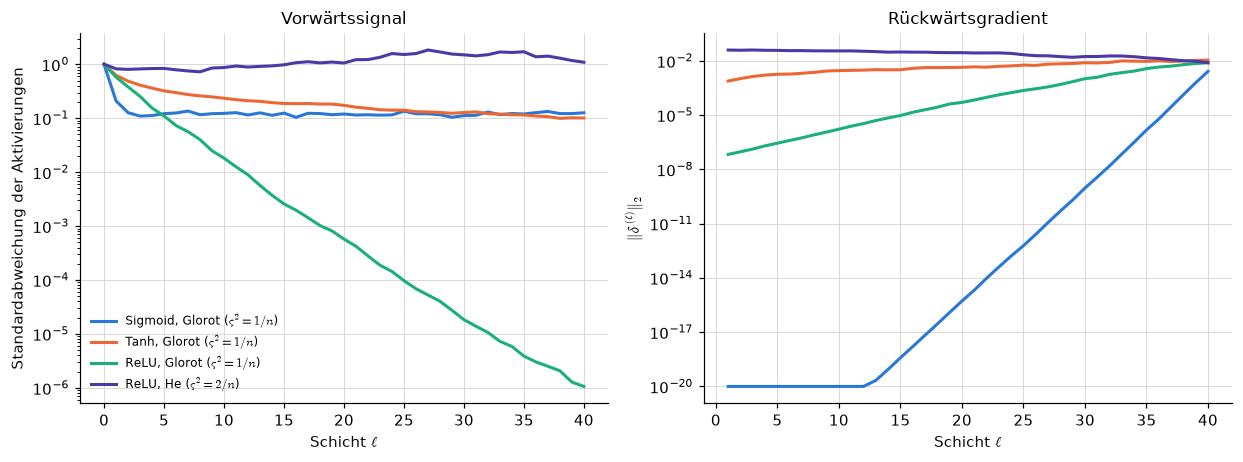

Faktor gamma je Schicht in Rückwärtsrichtung (Steigung im halblogarithmischen Diagramm):
  Sigmoid, Glorot      gamma = 0.2342
  Tanh, Glorot         gamma = 0.9449
  ReLU, Glorot (1/n)   gamma = 0.7340
  ReLU, He (2/n)       gamma = 1.0363

Vergleichswerte: 1/4 = 0,2500 (Schranke aus Satz 2.2), 1/sqrt(2) = 0,7071 (Varianzhalbierung durch ReLU), 1 = varianzerhaltend


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.3))
layers = np.arange(1, 41)

for (label, std, norms), color in zip(results.values(), PALETTE):
    axes[0].semilogy(np.arange(len(std)), np.maximum(std, 1e-20), color=color, label=label)
    axes[1].semilogy(layers, np.maximum(norms, 1e-20), color=color, label=label)

axes[0].set_xlabel("Schicht $\\ell$")
axes[0].set_ylabel(r"Standardabweichung der Aktivierungen")
axes[0].set_title("Vorwärtssignal")
axes[0].legend(fontsize=8)

axes[1].set_xlabel("Schicht $\\ell$")
axes[1].set_ylabel(r"$\|\delta^{(\ell)}\|_2$")
axes[1].set_title("Rückwärtsgradient")

plt.tight_layout()
plt.show()

# Empirischer Faktor gamma je Schicht, gemessen in Rueckwaertsrichtung:
# gamma < 1 bedeutet, dass der Gradient auf dem Weg zur Eingangsschicht schrumpft.
print("Faktor gamma je Schicht in Rückwärtsrichtung (Steigung im halblogarithmischen Diagramm):")
for name, (_, _, norms) in results.items():
    positive = norms > 0
    slope = np.polyfit(layers[positive], np.log(norms[positive]), 1)[0]
    print(f"  {name:<20} gamma = {np.exp(-slope):.4f}")

print("\nVergleichswerte: 1/4 = 0,2500 (Schranke aus Satz 2.2), "
      "1/sqrt(2) = 0,7071 (Varianzhalbierung durch ReLU), 1 = varianzerhaltend")

**Abbildung 5.3** — Links das Vorwärtssignal, rechts der Rückwärtsgradient über der Tiefe, beide
halblogarithmisch. Eine Gerade in dieser Darstellung bedeutet exponentielles Verhalten; ihre
Steigung ist $\log\gamma$.

Die Beobachtungen decken sich mit der Theorie:

* **Sigmoid** dämpft am stärksten — der Faktor $\varphi' \le \tfrac14$ aus Satz 2.2 schlägt in
  jeder Schicht zu, und zusätzlich verschiebt der von null verschiedene Mittelwert der Ausgabe
  ($\sigma > 0$) das Signal systematisch.
* **ReLU mit Glorot-Initialisierung** verliert pro Schicht rund den Faktor $1/\sqrt{2}$ im
  Vorwärtssignal — genau der Halbierung der Varianz durch das Abschneiden des negativen Astes
  entsprechend.
* **ReLU mit He-Initialisierung** hält $\gamma \approx 1$: Vorwärtssignal und Gradientennorm
  bleiben über $40$ Schichten hinweg auf derselben Größenordnung. Genau das macht das Training
  tiefer Netze überhaupt erst möglich.

Damit schließt sich der Bogen zu Notebook 2: Verschwindende Gradienten sind kein Fehler des
Gradientenverfahrens, sondern ein Konditionierungsproblem der Zielfunktion. Die Gegenmaßnahmen —
Initialisierung, Normalisierungsschichten, Residualverbindungen — verändern nicht den Optimierer,
sondern die Landschaft, auf der er arbeitet.

<a id="6"></a>
## 6 Übungsaufgaben

**Aufgabe 5.1 (Softmax und Kreuzentropie).** Zeigen Sie, dass der Gradient der kategorialen
Kreuzentropie $\mathcal{L} = -\log s_y$ nach den Logits die bemerkenswert einfache Form
$\partial\mathcal{L}/\partial z = s - e_y$ besitzt. Nutzen Sie dazu Satz 4.3 und erklären Sie,
weshalb sich der Faktor $s_i$ der Jacobi-Matrix gegen den Nenner der Ableitung von $\log$ kürzt.

**Aufgabe 5.2 (Dying ReLU).** Konstruieren Sie ein Netz und eine Lernrate, bei denen nach wenigen
Schritten mehr als die Hälfte der Einheiten dauerhaft inaktiv ist. Weisen Sie nach, dass Leaky
ReLU mit $\alpha = 0{,}01$ das Problem behebt, und diskutieren Sie den Preis.

**Aufgabe 5.3 (Sättigung und Lernrate).** Zeigen Sie analytisch, dass für ein Sigmoid-Neuron mit
quadratischem Verlust der Gradient bei stark falscher Vorhersage *gegen null* geht, während er bei
Kreuzentropieverlust beschränkt bleibt. Was folgt daraus für die Wahl der Verlustfunktion?

**Aufgabe 5.4 (He-Initialisierung herleiten).** Führen Sie die Varianzrechnung für ReLU explizit
durch: Zeigen Sie $\operatorname{Var}(\operatorname{ReLU}(z)) = \tfrac12\operatorname{Var}(z)$ für
symmetrisch verteiltes $z$ mit Mittelwert $0$ und folgern Sie $\varsigma^2 = 2/n_{\text{in}}$.
Prüfen Sie das Ergebnis mit `propagate` für weitere Werte von `gain`.

**Aufgabe 5.5 (Residualverbindungen).** Erweitern Sie `propagate` um Residualverbindungen
$a^{(\ell)} = a^{(\ell-1)} + \varphi(W^{(\ell)}a^{(\ell-1)})$. Zeigen Sie empirisch, dass die
Gradientennorm nun auch bei ungünstiger Initialisierung nicht mehr exponentiell zerfällt, und
erklären Sie dies anhand der Kettenregel für die Summe.

---

## Literatur

- Cybenko, G. (1989). *Approximation by Superpositions of a Sigmoidal Function.* Mathematics of
  Control, Signals and Systems 2, S. 303–314.
- Glorot, X., Bengio, Y. (2010). *Understanding the difficulty of training deep feedforward neural
  networks.* AISTATS 2010, S. 249–256.
- Goodfellow, I., Bengio, Y., Courville, A. (2016). *Deep Learning.* MIT Press, Kapitel 6 und 8.
- He, K., Zhang, X., Ren, S., Sun, J. (2015). *Delving Deep into Rectifiers.* ICCV 2015,
  S. 1026–1034.
- Hendrycks, D., Gimpel, K. (2016). *Gaussian Error Linear Units (GELUs).* arXiv:1606.08415.
- Hornik, K. (1991). *Approximation Capabilities of Multilayer Feedforward Networks.* Neural
  Networks 4(2), S. 251–257.
- Nair, V., Hinton, G. E. (2010). *Rectified Linear Units Improve Restricted Boltzmann Machines.*
  ICML 2010, S. 807–814.